# Sentiment Classification using Twitter Dataset 🐦  
### Machine Learning Project – Colab Notebook


## Load Twitter Dataset


In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/AniShpiz/ML1/refs/heads/main/sentiment.csv")
df_original = df.copy()

## Checking for Missing Values and '?' Placeholders  
Before processing the dataset, we check for missing values (NaN) and placeholder question marks ('?') that may indicate missing data.


In [ ]:
print("Null and ? check:")

for col in df.columns:
    # Count NaNs in this column
    nan_count = df[col].isnull().sum()

    # Count "?" strings in this column
    question_count = (df[col].astype(str) == "?").sum()

    # Print total
    print(f"{col}: , Nulls: {nan_count} , ?: {question_count}, Total: {nan_count + question_count}")


Null and ? check:
id: , Nulls: 0 , ?: 0, Total: 0
text: , Nulls: 0 , ?: 0, Total: 0
sentiment: , Nulls: 0 , ?: 527, Total: 527
type: , Nulls: 0 , ?: 0, Total: 0
post_datetime: , Nulls: 0 , ?: 507, Total: 507
timezone: , Nulls: 0 , ?: 507, Total: 507
post_likes: , Nulls: 0 , ?: 486, Total: 486
posts_retweets: , Nulls: 0 , ?: 486, Total: 486
embedded_content_url: , Nulls: 30757 , ?: 0, Total: 30757
username: , Nulls: 0 , ?: 480, Total: 480
checkmark: , Nulls: 0 , ?: 480, Total: 480
account_creation_date: , Nulls: 0 , ?: 480, Total: 480
email: , Nulls: 0 , ?: 480, Total: 480
birthday: , Nulls: 0 , ?: 480, Total: 480
followers: , Nulls: 0 , ?: 480, Total: 480
profile_picture: , Nulls: 11791 , ?: 480, Total: 12271
previous_posts_count: , Nulls: 0 , ?: 480, Total: 480


## removing ? (change to null)

In [ ]:
import numpy as np

df.replace("?", np.nan, inplace=True)


## Buckitize Non-categorial features
In this step, we apply several transformations to prepare the dataset for modeling.  
We bucketize non-categorical features and perform various manipulations to extract meaningful features and ensure numerical consistency.

In [ ]:
from datetime import datetime

df = df.dropna(subset=['sentiment'])

# Extract hour from post datetime
df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce')
df['post_hour'] = df['post_datetime'].dt.hour

# Fill missing post_hour values with random hour from 4 equal time blocks
possible_hours = list(range(0, 24))  # 0–23
df.loc[df['post_hour'].isna(), 'post_hour'] = np.random.choice(possible_hours, size=df['post_hour'].isna().sum())

# Bucket post_hour into time of day
def bucketize_hour(h):
    if pd.isnull(h): return 'nan'
    if 0 <= h <= 5: return 'Night'
    elif 6 <= h <= 11: return 'Morning'
    elif 12 <= h <= 17: return 'Afternoon'
    else: return 'Evening'

df['post_time_of_day'] = df['post_hour'].apply(bucketize_hour)

# Bucket followers
def bucketize_followers(f):
    f = pd.to_numeric(f)
    if f <= 100: return '0-100'
    elif f <= 500: return '101-500'
    elif f <= 1000: return '501-1K'
    elif f <= 10000: return '1K-10K'
    else: return '10K+'

df['followers_bucket'] = df['followers'].apply(bucketize_followers)

# Bucket post_likes
def bucketize_likes(x):
    x = pd.to_numeric(x)
    if x == 0: return '0'
    elif x <= 5: return '1-5'
    elif x <= 20: return '6-20'
    elif x <= 100: return '21-100'
    else: return '100+'

df['post_likes_bucket'] = df['post_likes'].apply(bucketize_likes)

# Bucket posts_retweets
def bucketize_retweets(x):
    x = pd.to_numeric(x)
    if x == 0: return '0'
    elif x <= 5: return '1-5'
    elif x <= 20: return '6-20'
    elif x <= 100: return '21-100'
    else: return '100+'

df['post_retweets_bucket'] = df['posts_retweets'].apply(bucketize_retweets)

# Bucket account creation year
df['account_creation_date'] = pd.to_datetime(df['account_creation_date'], errors='coerce')
df['account_year'] = df['account_creation_date'].dt.year

def bucketize_account_year(y):
    y = pd.to_numeric(y)
    if pd.isnull(y): return 'Unknown'
    elif y < 2010: return 'Before 2010'
    elif y <= 2015: return '2010-2015'
    elif y <= 2020: return '2016-2020'
    else: return '2021+'

df['account_year_bucket'] = df['account_year'].apply(bucketize_account_year)

# Fill missing birthdays with the average date
df['birthday'] = df['birthday'].fillna('1987-08-26')

# Convert birthday column to datetime and extract month
df['birthday'] = pd.to_datetime(df['birthday'], errors='coerce')
df['birth_month'] = df['birthday'].dt.month

# Bucket birth_month into months
def bucketize_birth_month(m):
    if pd.isnull(m): return 0
    return str(int(m))

df['birth_month_bucket'] = df['birth_month'].apply(bucketize_birth_month)

df['birth_year'] = df['birthday'].dt.year
current_year = datetime.now().year
df['user_age'] = current_year - df['birth_year']


def bucketize_age(age):
    if pd.isnull(age): return 'Unknown'
    if age < 18: return 'Under 18'
    elif age <= 24: return '18-24'
    elif age <= 29: return '25-29'
    elif age <= 34: return '30-34'
    elif age <= 39: return '35-39'
    elif age <= 44: return '40-44'
    elif age <= 49: return '45-49'
    elif age <= 64: return '50-64'
    elif age <= 74: return '65-74'
    elif age <= 84: return '75-84'
    elif age <= 94: return '85-94'
    else: return '95+'


df['age_bucket'] = df['user_age'].apply(bucketize_age)

# Fill missing values in previous_posts_count with 0
df['previous_posts_count'] = df['previous_posts_count'].fillna(0)

# Bucket previous_posts into defined ranges
def bucketize_previous_posts(x):
    x = pd.to_numeric(x, errors='coerce')
    if pd.isnull(x): return 'Unknown'
    if x == 0: return '0'
    elif x == 1: return '1'
    elif x <= 5: return '2-5'
    elif x <= 10: return '6-10'
    elif x <= 20: return '11-20'
    elif x <= 50: return '21-50'
    elif x <= 100: return '51-100'
    elif x <= 200: return '101-200'
    else: return '200+'

df['previous_posts_bucket'] = df['previous_posts_count'].apply(bucketize_previous_posts)

# Create a binary categorical column indicating if a link exists
df['has_link'] = df['embedded_content_url'].notnull().astype(int)

# Fill missing values in 'checkmark' column with 'none'
df['checkmark'] = df['checkmark'].fillna('none')

<ipython-input-41-74b2dfc7a224>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce')
<ipython-input-41-74b2dfc7a224>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['post_hour'] = df['post_datetime'].dt.hour
<ipython-input-41-74b2dfc7a224>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

## Feature Distributions – Histograms  
To better understand the structure and spread of our data, we visualize the distribution of key numerical features using histograms.  
This helps us identify general patterns, detect skewness, and verify that there are no extreme outliers that could impact the model’s learning process.


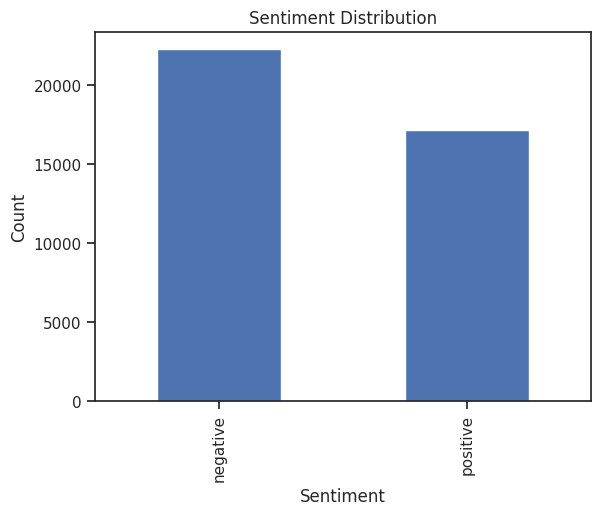

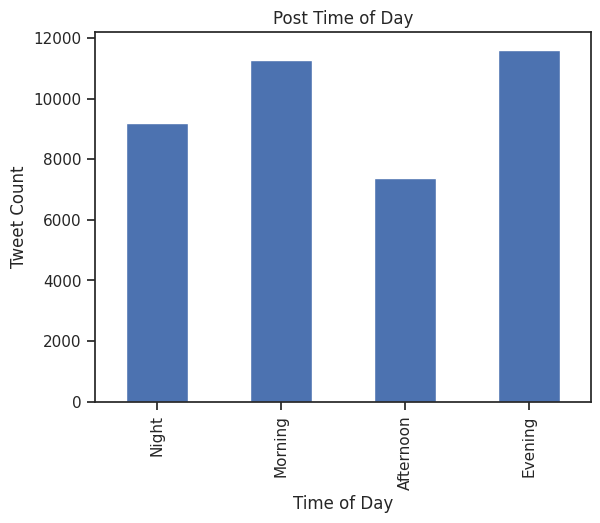

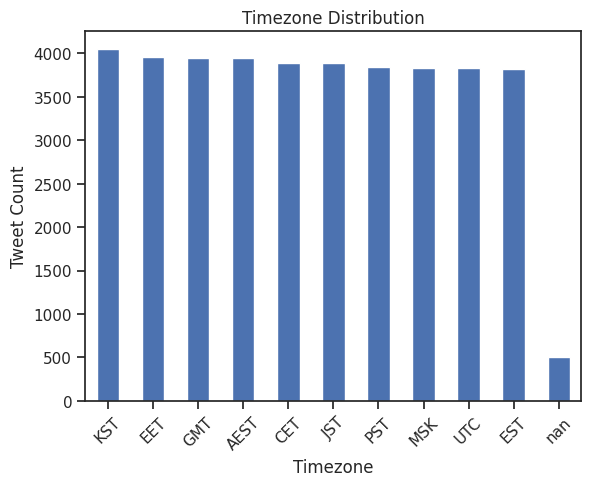

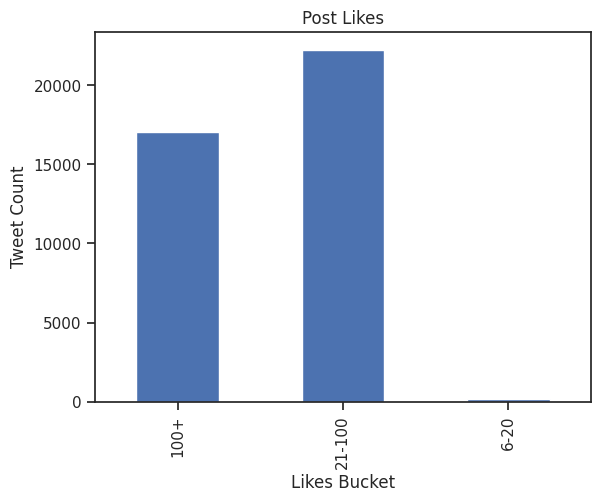

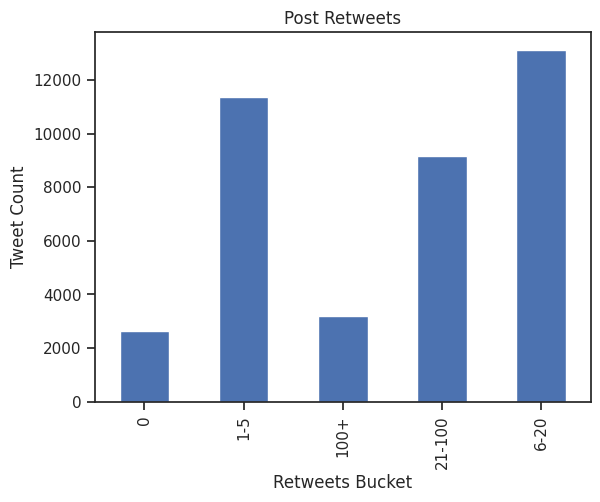

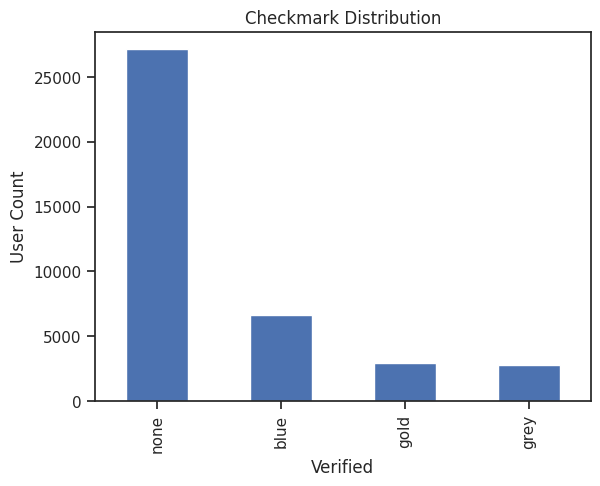

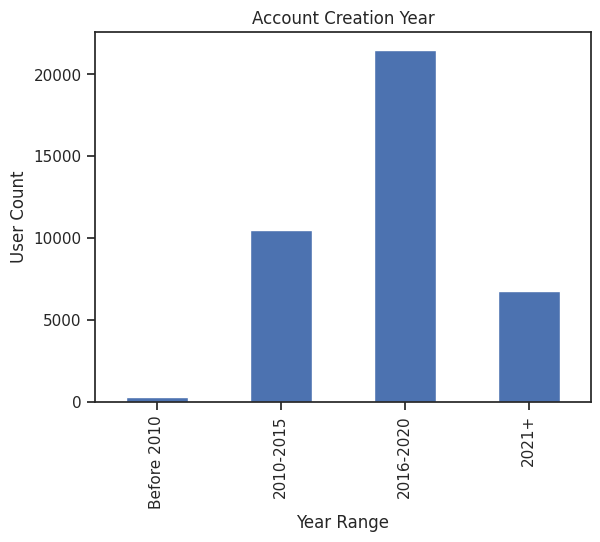

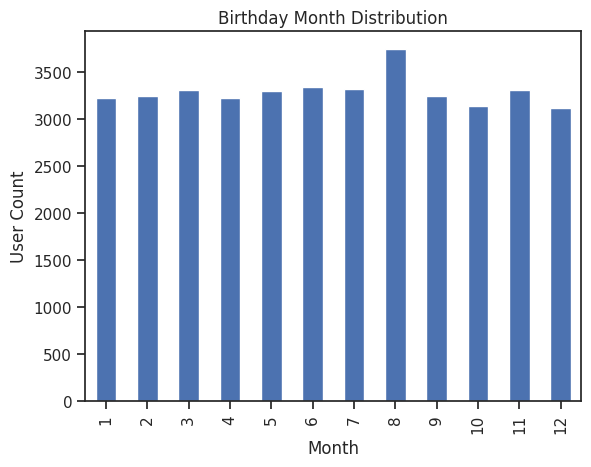

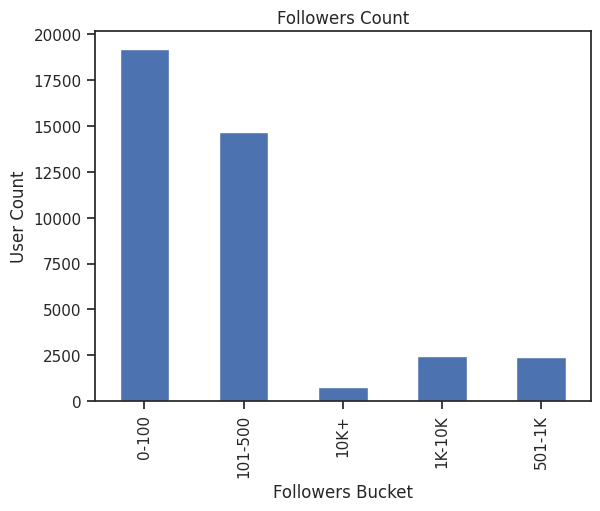

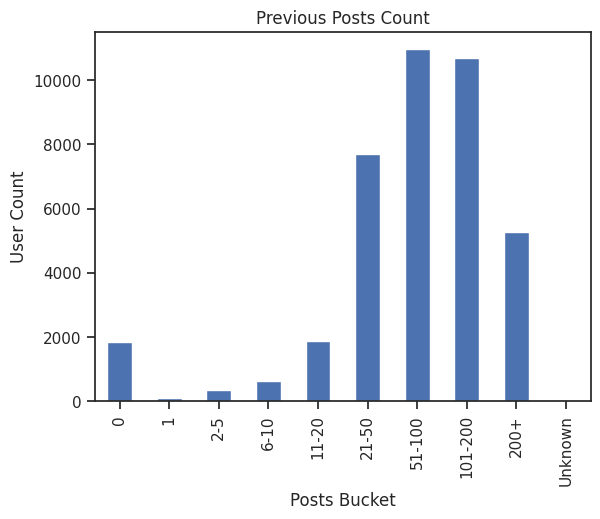

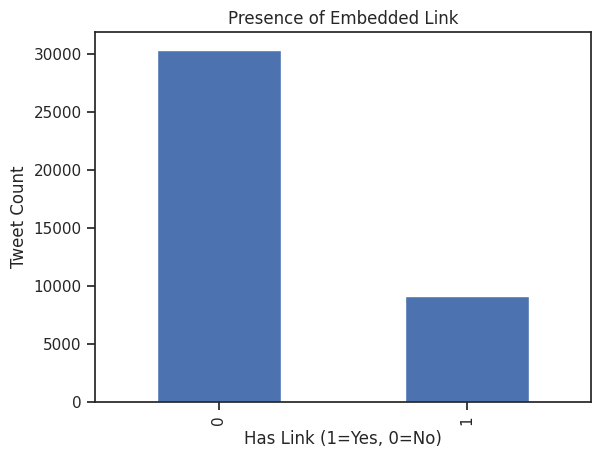

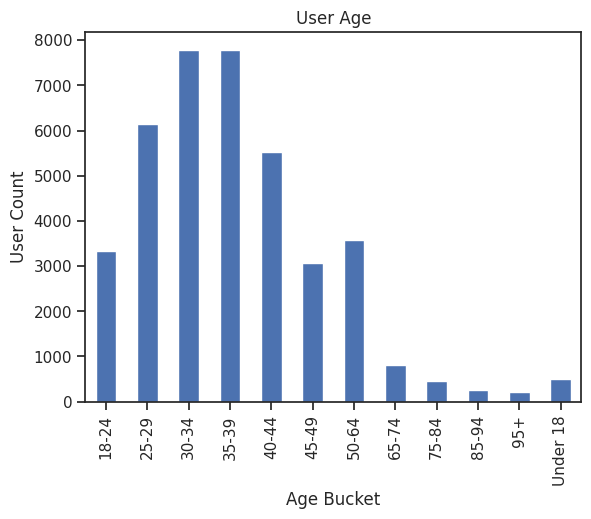

In [ ]:
import matplotlib.pyplot as plt

# Sentiment
df['sentiment'].value_counts(dropna=False).plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Post time of day
df['post_time_of_day'].value_counts(dropna=False).reindex(['Night', 'Morning', 'Afternoon', 'Evening']).plot(kind='bar')


plt.title("Post Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Tweet Count")
plt.show()

# Timezone
df['timezone'].value_counts(dropna=False).plot(kind='bar')
plt.title("Timezone Distribution")
plt.xlabel("Timezone")
plt.ylabel("Tweet Count")
plt.xticks(rotation=45)
plt.show()

# Post likes (bucketized)
df['post_likes_bucket'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.title("Post Likes")
plt.xlabel("Likes Bucket")
plt.ylabel("Tweet Count")
plt.show()

# Post retweets (bucketized)
df['post_retweets_bucket'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.title("Post Retweets")
plt.xlabel("Retweets Bucket")
plt.ylabel("Tweet Count")
plt.show()

# Checkmark
df['checkmark'].value_counts(dropna=False).plot(kind='bar')
plt.title("Checkmark Distribution")
plt.xlabel("Verified")
plt.ylabel("User Count")
plt.show()

# Account creation year (bucketized)
df['account_year_bucket'].value_counts(dropna=False).reindex(['Before 2010', '2010-2015', '2016-2020', '2021+']).plot(kind='bar')
plt.title("Account Creation Year")
plt.xlabel("Year Range")
plt.ylabel("User Count")
plt.show()

# Birthday month
df['birth_month_bucket'].value_counts(dropna=False).sort_index(key=lambda x: x.astype(int)).plot(kind='bar')
plt.title("Birthday Month Distribution")
plt.xlabel("Month")
plt.ylabel("User Count")
plt.show()

# Followers (bucketized)
df['followers_bucket'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.title("Followers Count")
plt.xlabel("Followers Bucket")
plt.ylabel("User Count")
plt.show()

# Previous posts (bucketized)
df['previous_posts_bucket'].value_counts(dropna=False).reindex(['0', '1', '2-5', '6-10', '11-20', '21-50', '51-100', '101-200', '200+', 'Unknown']).plot(kind='bar')
plt.title("Previous Posts Count")
plt.xlabel("Posts Bucket")
plt.ylabel("User Count")
plt.show()

df['has_link'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.title("Presence of Embedded Link")
plt.xlabel("Has Link (1=Yes, 0=No)")
plt.ylabel("Tweet Count")
plt.show()

df['age_bucket'].value_counts(dropna=False).sort_index().plot(kind='bar')
plt.title("User Age")
plt.xlabel("Age Bucket")
plt.ylabel("User Count")
plt.show()




The dataset presents a relatively balanced distribution between the positive and negative sentiment labels, with a slight predominance of the negative category. The number of missing values (NaNs) is very small and can be safely removed from the analysis, as they do not contribute any meaningful information to our supervised learning task. At this stage, no further data balancing is required.

## Fixing Data Types for Analysis and Modeling  


### Converting Numeric-like Columns to True Numeric Format  
Some features were read from the CSV as strings or objects, although they represent numeric values.  
We convert them to proper numeric types to enable calculations.


In [ ]:
# Convert numeric columns to proper numeric types
df['post_likes'] = pd.to_numeric(df['post_likes'], errors='coerce')
df['posts_retweets'] = pd.to_numeric(df['posts_retweets'], errors='coerce')
df['followers'] = pd.to_numeric(df['followers'], errors='coerce')
df['previous_posts_count'] = pd.to_numeric(df['previous_posts_count'], errors='coerce')


### Converting Date and Time Columns to Datetime Format  
Some features contain date or time information but are stored as plain text.  
We convert them to proper `datetime` format to enable accurate time-based processing, filtering, and feature extraction.


In [ ]:
# Convert date columns to datetime
df['post_datetime'] = pd.to_datetime(df['post_datetime'], errors='coerce', dayfirst=True)
df['account_creation_date'] = pd.to_datetime(df['account_creation_date'], errors='coerce', dayfirst=True)
df['birthday'] = pd.to_datetime(df['birthday'], errors='coerce', dayfirst=True)

# Extract useful numeric features from dates
df['post_hour'] = df['post_datetime'].dt.hour
df['account_year'] = df['account_creation_date'].dt.year
df['birth_year'] = df['birthday'].dt.year
df['birth_month'] = df['birthday'].dt.month


### Converting the 'sentiment' Feature to Numeric Labels  
The `sentiment` column originally contained text labels: `'positive'` and `'negative'`.  
We convert these to numeric values: `1` for positive sentiment and `-1` for negative sentiment, to make the data compatible with machine learning models.  
Additionally, to avoid unexpected issues with remaining missing values, we assign the value `0` to any rows where `sentiment` is still empty after preprocessing.


In [ ]:
# Encode sentiment to numeric labels
sentiment_mapping = {
    'positive': 1,
    '': 0,
    'negative': -1
}

df['sentiment_numeric'] = df['sentiment'].map(sentiment_mapping)


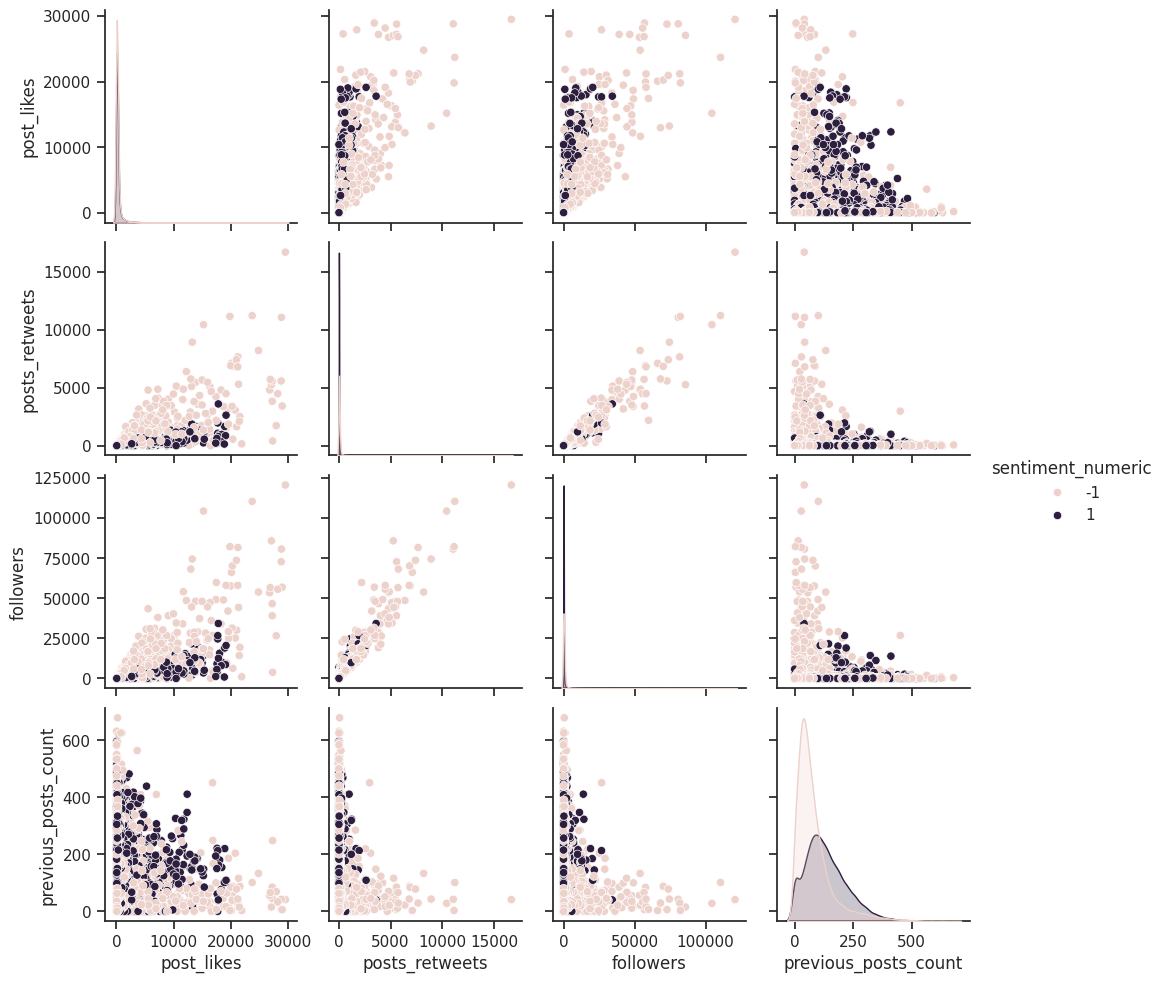

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numerical columns we want to visualize
selected_features = ['post_likes', 'posts_retweets', 'followers', 'previous_posts_count', 'sentiment_numeric']

# Create a subset DataFrame with the selected features
df_pairplot = df[selected_features]

sns.set_theme(style="ticks")
sns.pairplot(df_pairplot, hue="sentiment_numeric")
plt.show()


## Correlation Matrix Between Numerical Features and the Target Variable  
We compute a correlation matrix to measure the relationship between selected numerical features and the numeric sentiment variable. This helps identify which features are most strongly associated with the target and may be valuable for model training.


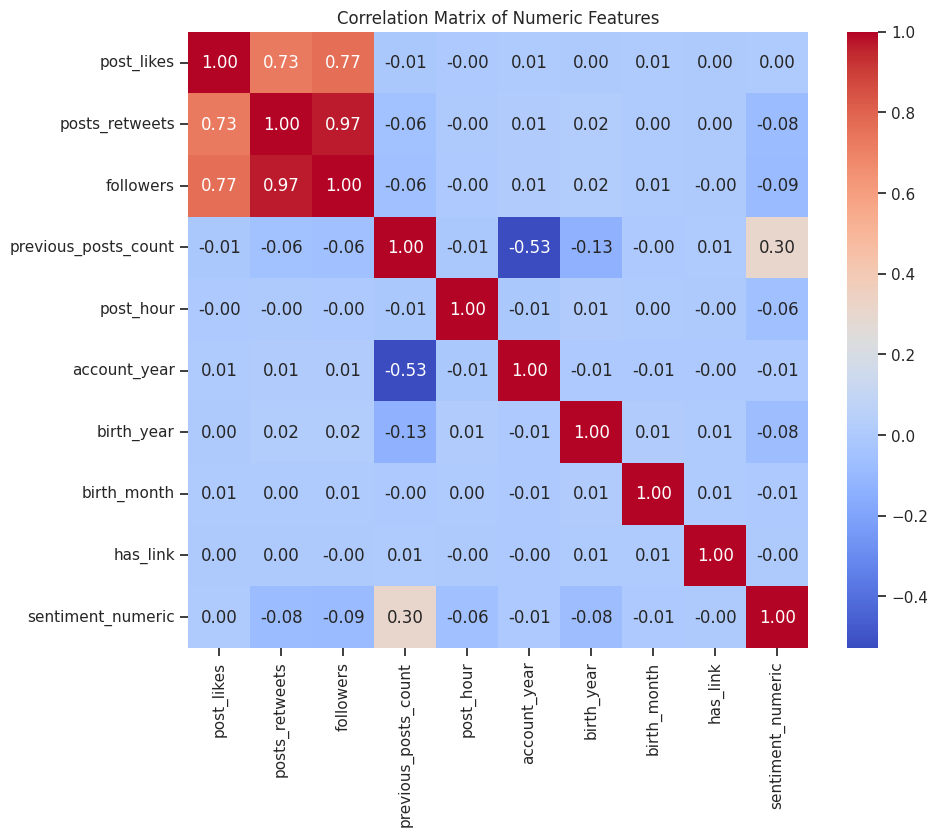

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation
numeric_cols = ['post_likes', 'posts_retweets', 'followers', 'previous_posts_count',
                'post_hour', 'account_year', 'birth_year', 'birth_month','has_link','sentiment_numeric']

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()


<div dir="rtl" align="right">



In the feature extraction stage, we used a fixed number of features without relying on their order over time.
Each row in the data represents a single, independent post, so there's no need to consider the sequence of posts.
The features we used — like number of likes, followers, verification status, and profile picture — are not time-based, so analyzing them as-is makes the process simpler and more focused.



## Feature Engineering: Encoding, Transformation, and Extraction  
This section includes various transformations, such as creating dummy variables, binary indicators, text-based features, and domain-based logic to enrich the dataset.


In [ ]:
# One-hot encode
timezone_dummies = pd.get_dummies(df['timezone'], prefix='tz', dummy_na=False)
checkmark_dummies = pd.get_dummies(df['checkmark'], prefix='cm', dummy_na=False)
post_time_dummies = pd.get_dummies(df['post_time_of_day'], prefix='ptod', dummy_na=False)
type_dummies = pd.get_dummies(df['type'], prefix='tpe', dummy_na=False)
account_year_dummies = pd.get_dummies(df['account_year_bucket'], prefix='ay', dummy_na=False)
birth_month_dummies = pd.get_dummies(df['birth_month_bucket'], prefix='bm', dummy_na=False)
age_dummies = pd.get_dummies(df['age_bucket'], prefix='_ag', dummy_na=False)

# Remove old dummy columns before creating new ones (prevent duplicates on re-run)
def remove_dummies(df, prefix):
    cols_to_remove = [col for col in df.columns if col.startswith(prefix)]

    return df.drop(columns=cols_to_remove, errors='ignore')

df = remove_dummies(df, 'tz')
df = remove_dummies(df, 'cm')
df = remove_dummies(df, 'ptod')
df = remove_dummies(df, 'tpe')
df = remove_dummies(df, 'ay')
df = remove_dummies(df, 'bm')
df = remove_dummies(df, '_ag')

df = pd.concat([df, timezone_dummies, checkmark_dummies, post_time_dummies, type_dummies, account_year_dummies, birth_month_dummies,age_dummies], axis=1)


# Create binary feature for legitimate email domains
legit_domains_set = {
    "gmail.com", "googlemail.com", "outlook.com", "hotmail.com", "hotmail.co.uk", "hotmail.it", "hotmail.fr",
    "yahoo.com", "yahoo.co.uk", "yahoo.fr", "yahoo.ca", "yahoo.it", "yahoo.de", "yahoo.com.au", "yahoo.co.in",
    "yahoo.com.br", "yahoo.com.tw", "rocketmail.com", "ymail.com",
    "aol.com", "msn.com", "live.com", "live.nl", "live.dk", "live.no", "live.se", "me.com", "icloud.com", "mac.com",
    "gmx.de", "web.de", "mail.ru", "naver.com", "163.com", "btinternet.com", "online.no", "att.net", "sbcglobal.net",
    "verizon.net", "comcast.net", "bigpond.com", "bigpond.net.au"
}

def is_legit_email(email):
    try:
        domain = email.split('@')[-1].lower()
        return int(domain in legit_domains_set)
    except:
        return 0

df['legit_email'] = df['email'].apply(is_legit_email)


df['has_profile_picture'] = df['profile_picture'].notnull().astype(int)


df['num_hashtags'] = df['text'].astype(str).str.count('#')

df['tweet_length'] = df['text'].astype(str).apply(len)

df['tweet_word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print(df.columns)
print(df.count)

Index(['id', 'text', 'sentiment', 'type', 'post_datetime', 'timezone',
       'post_likes', 'posts_retweets', 'embedded_content_url', 'username',
       'checkmark', 'account_creation_date', 'email', 'birthday', 'followers',
       'profile_picture', 'previous_posts_count', 'post_hour',
       'post_time_of_day', 'followers_bucket', 'post_likes_bucket',
       'post_retweets_bucket', 'account_year', 'account_year_bucket',
       'birth_month', 'birth_month_bucket', 'birth_year', 'user_age',
       'age_bucket', 'previous_posts_bucket', 'has_link', 'sentiment_numeric',
       'tz_AEST', 'tz_CET', 'tz_EET', 'tz_EST', 'tz_GMT', 'tz_JST', 'tz_KST',
       'tz_MSK', 'tz_PST', 'tz_UTC', 'cm_blue', 'cm_gold', 'cm_grey',
       'cm_none', 'ptod_Afternoon', 'ptod_Evening', 'ptod_Morning',
       'ptod_Night', 'tpe_post', 'tpe_reply', 'tpe_retweet', 'ay_2010-2015',
       'ay_2016-2020', 'ay_2021+', 'ay_Before 2010', 'ay_Unknown', 'bm_1',
       'bm_10', 'bm_11', 'bm_12', 'bm_2', 'bm_3', 'bm_4',

## Correlation Analysis: New Features vs. Sentiment  
In this section, we explore the relationships between newly engineered features and the target variable (`sentiment`) using correlation analysis.


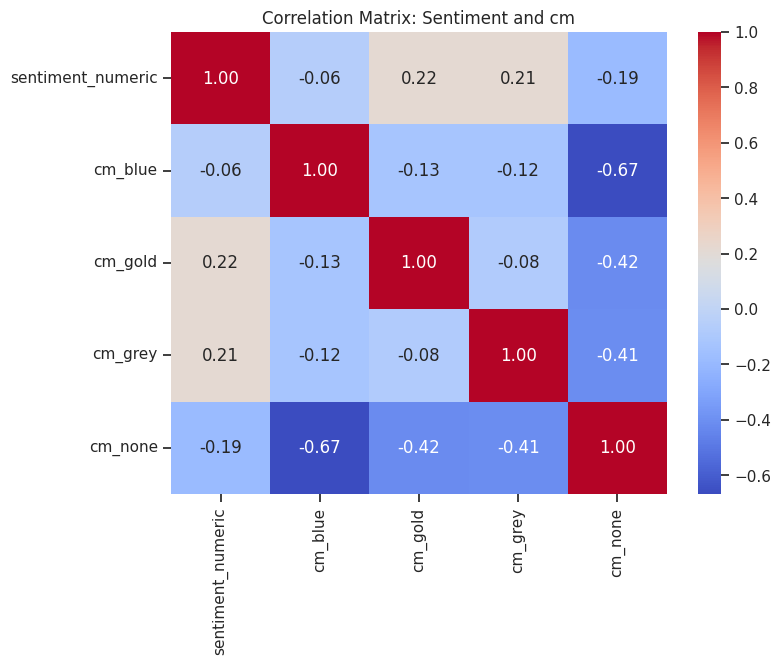

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('cm_')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and cm")
plt.show()


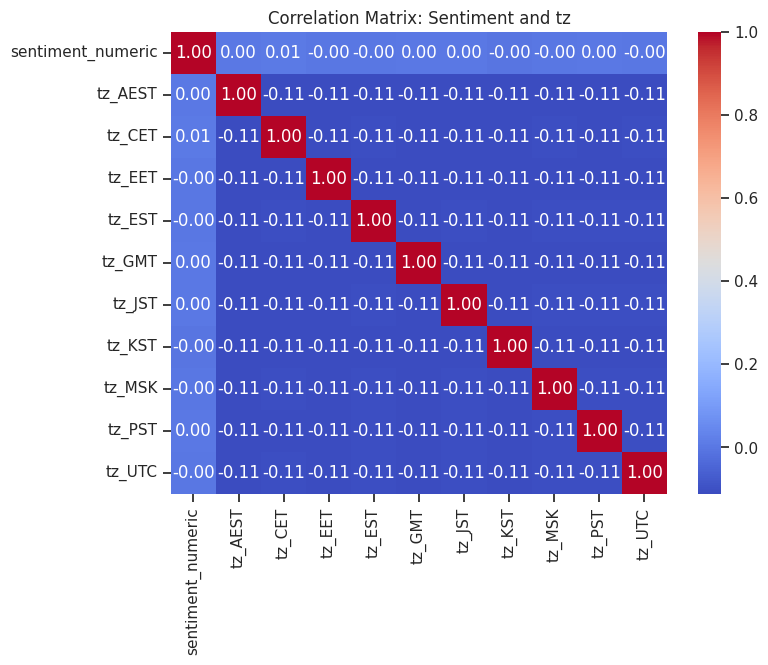

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('tz_')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and tz")
plt.show()


Based on the correlation matrix results, none of the timezone-related features showed a strong enough correlation with the target variable (`sentiment_numeric`).  
As a result, we chose not to include these features in the model, since they are unlikely to contribute meaningfully to its predictive performance.


### Checking Class Balance for `legit_email` and `sentiment_numeric`


In [ ]:
print(df['legit_email'].value_counts(dropna=False))
print(df['sentiment_numeric'].value_counts(dropna=False))


legit_email
1    30819
0     8654
Name: count, dtype: int64
sentiment_numeric
-1    22285
 1    17188
Name: count, dtype: int64


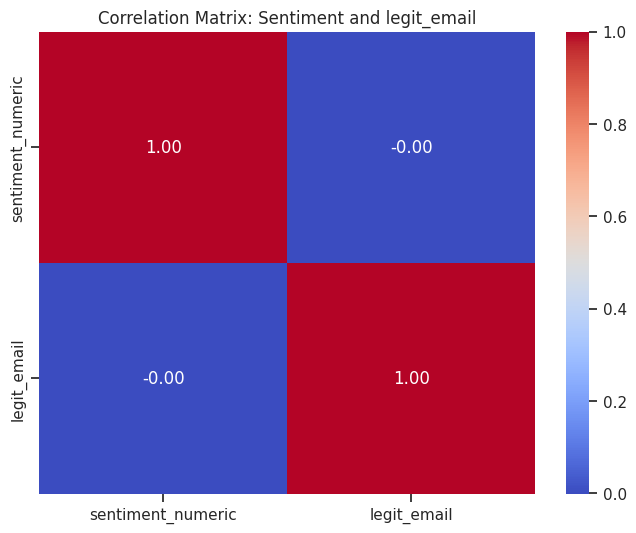

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric','legit_email']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and legit_email")
plt.show()


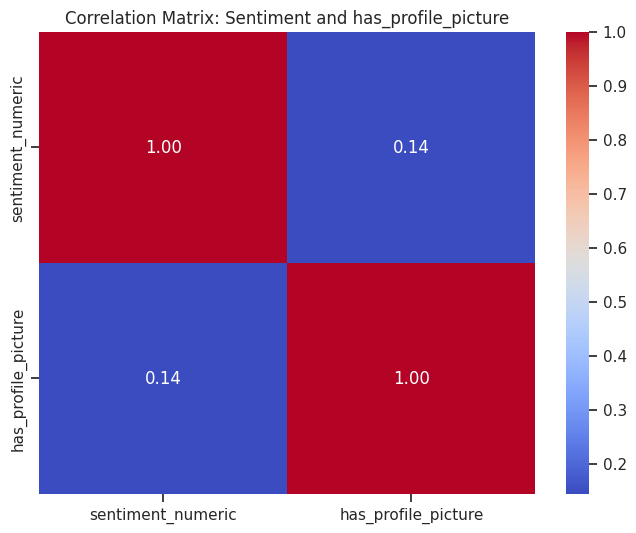

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric','has_profile_picture']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and has_profile_picture")
plt.show()


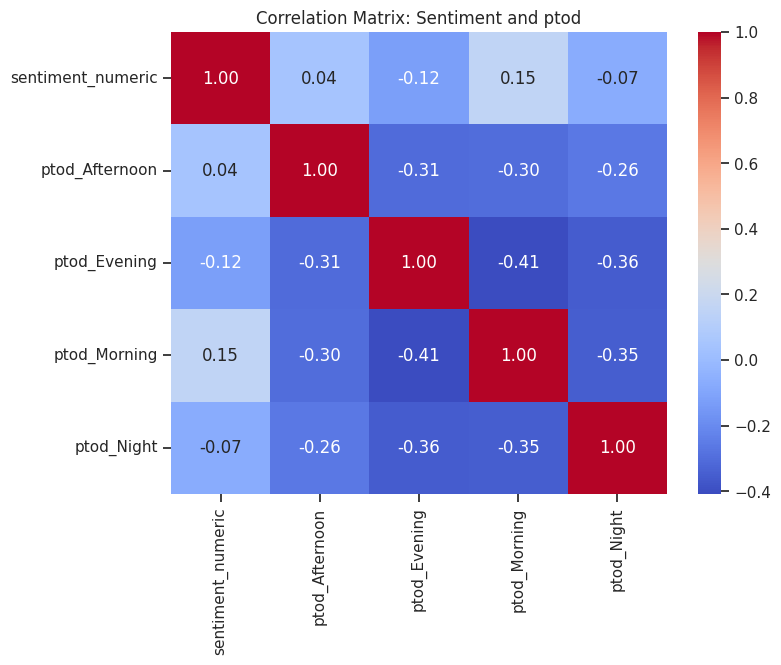

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('ptod_')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and ptod")
plt.show()


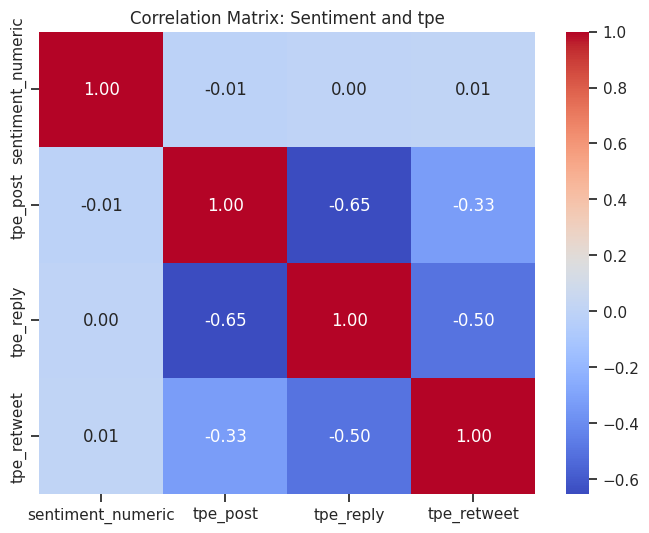

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('tpe_')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and tpe")
plt.show()


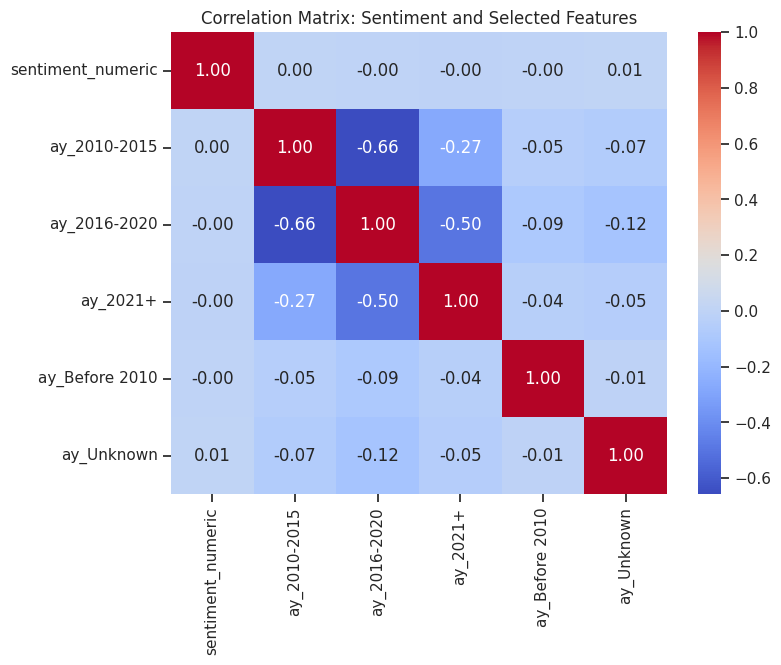

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('ay_')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and Selected Features")
plt.show()


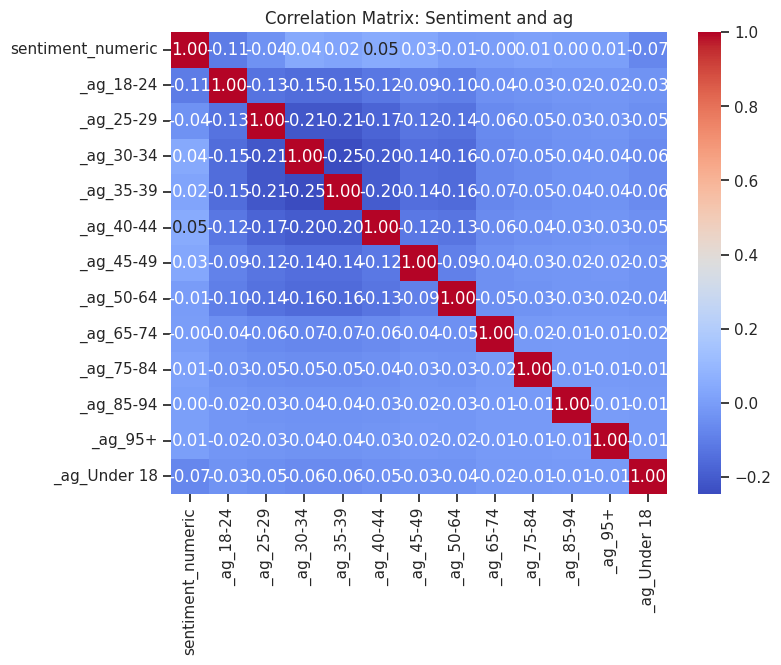

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['sentiment_numeric'] + \
       [col for col in df.columns if col.startswith('_ag')]

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and ag")
plt.show()


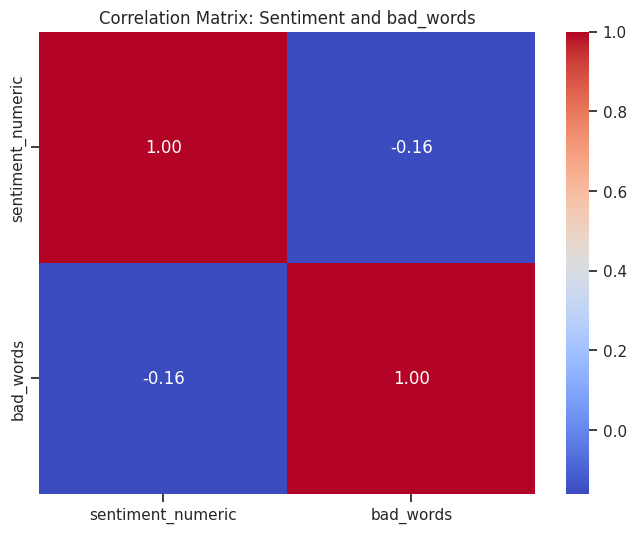

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df['bad_words'] = df['text'].astype(str).str.contains('bad|sad|shit|selfish|guilty|stressed|angry|lonely|pain|down|fearfull|broken|annoyed|fail|failure', case=False).astype(int)
cols = ['sentiment_numeric','bad_words']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and bad_words")
plt.show()


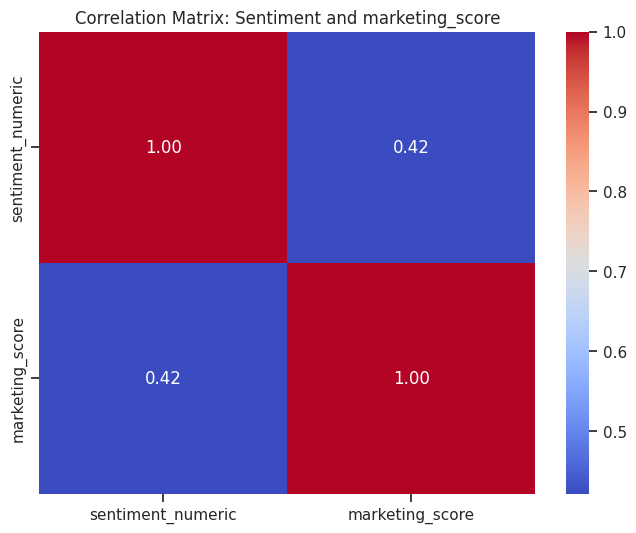

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df['marketing_score'] = (df['num_hashtags'] ) / (1 + df['tweet_length'])

cols = ['sentiment_numeric','marketing_score']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and marketing_score")
plt.show()

Text(0.5, 1.0, 'Correlation Matrix: Sentiment and drama_score')

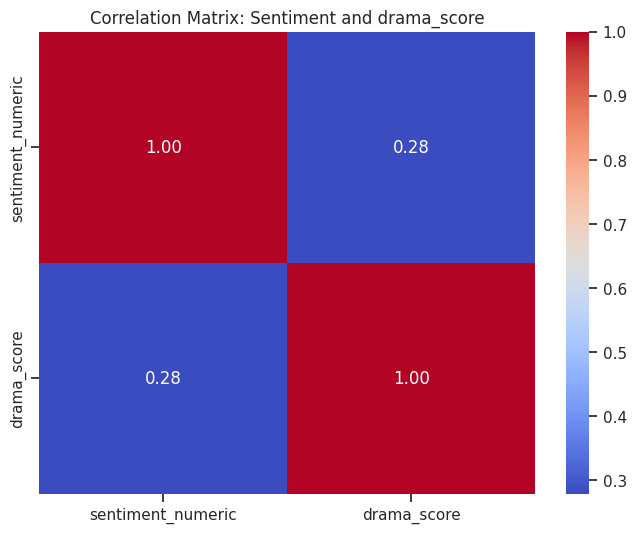

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df['drama_score'] = (
    df['tweet_length'] * 0.5 +
    df['num_hashtags'] * 2 +
    df['bad_words'] * 1.5
)


cols = ['sentiment_numeric','drama_score']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and drama_score")

Text(0.5, 1.0, 'Correlation Matrix: Sentiment and zoomer_energy')

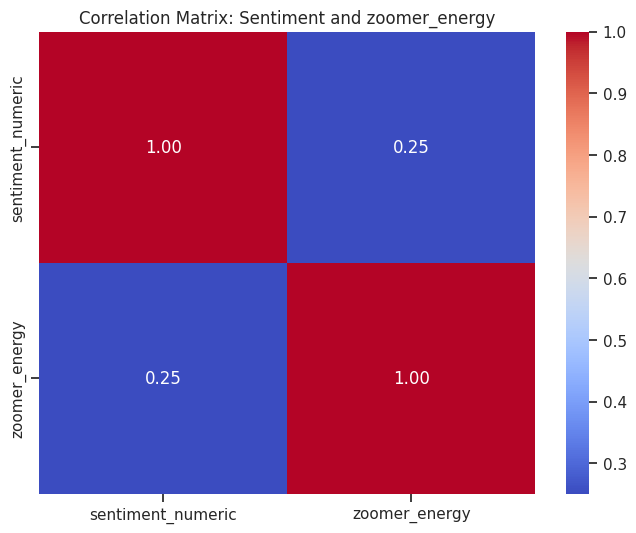

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['zoomer_energy'] = np.log(df['previous_posts_count'] + 1) / (df['_ag_18-24'] + 1)

cols = ['sentiment_numeric','zoomer_energy']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and zoomer_energy")

Text(0.5, 1.0, 'Correlation Matrix: Sentiment and credibility_impact')

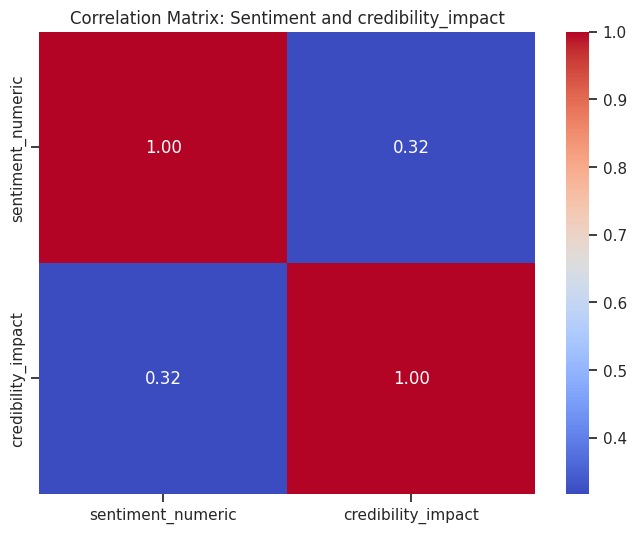

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df['credibility_impact'] = (

    (df['cm_gold'] * 2 + df['cm_grey'] * 2) *
    np.log1p(df['previous_posts_count'])
)

cols = ['sentiment_numeric','credibility_impact']

corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Sentiment and credibility_impact")

## Current Feature Set Overview  
A summary of the features constructed and selected so far, which will be considered for model training.


In [ ]:
print(df.columns)

Index(['id', 'text', 'sentiment', 'type', 'post_datetime', 'timezone',
       'post_likes', 'posts_retweets', 'embedded_content_url', 'username',
       'checkmark', 'account_creation_date', 'email', 'birthday', 'followers',
       'profile_picture', 'previous_posts_count', 'post_hour',
       'post_time_of_day', 'followers_bucket', 'post_likes_bucket',
       'post_retweets_bucket', 'account_year', 'account_year_bucket',
       'birth_month', 'birth_month_bucket', 'birth_year', 'user_age',
       'age_bucket', 'previous_posts_bucket', 'has_link', 'sentiment_numeric',
       'tz_AEST', 'tz_CET', 'tz_EET', 'tz_EST', 'tz_GMT', 'tz_JST', 'tz_KST',
       'tz_MSK', 'tz_PST', 'tz_UTC', 'cm_blue', 'cm_gold', 'cm_grey',
       'cm_none', 'ptod_Afternoon', 'ptod_Evening', 'ptod_Morning',
       'ptod_Night', 'tpe_post', 'tpe_reply', 'tpe_retweet', 'ay_2010-2015',
       'ay_2016-2020', 'ay_2021+', 'ay_Before 2010', 'ay_Unknown', 'bm_1',
       'bm_10', 'bm_11', 'bm_12', 'bm_2', 'bm_3', 'bm_4',

### Correlation Matrix – Selected Features

In this section, we compute and visualize the correlation matrix for a set of selected engineered features.
This helps us identify relationships between features, potential redundancy (high correlation),
and understand which variables might convey similar information.
Features with high mutual correlation (e.g., above 0.75 or below -0.75) may be candidates for removal or further analysis.


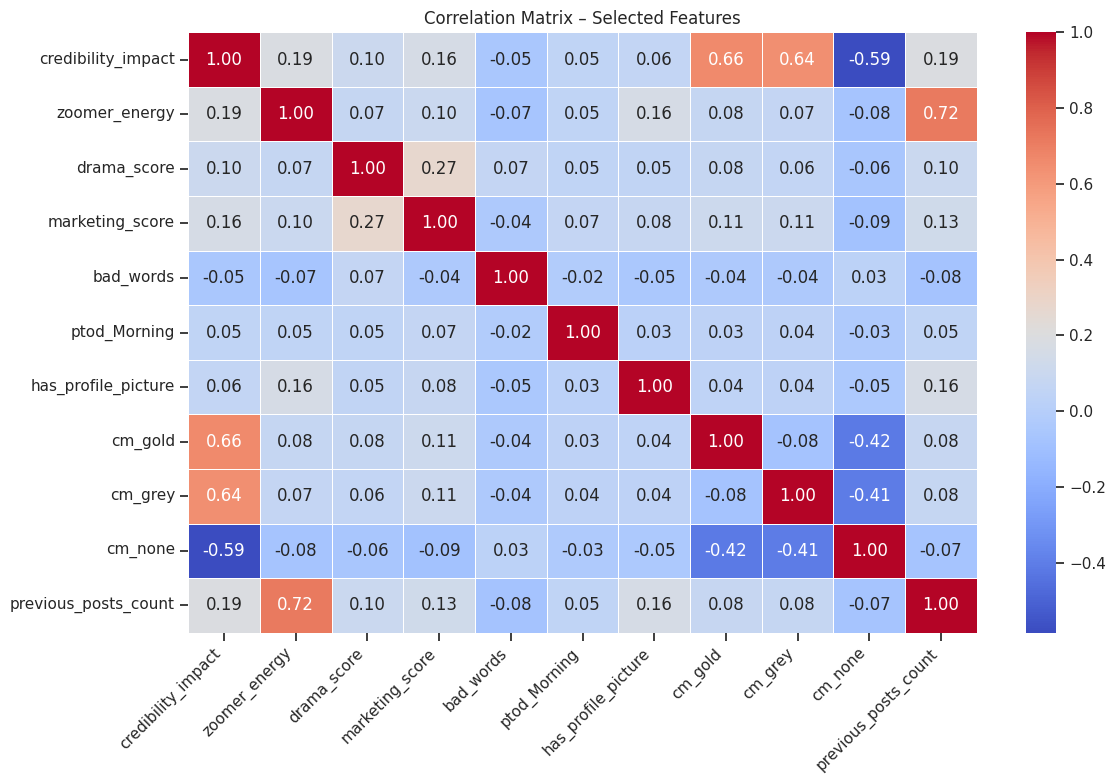

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = [
    'credibility_impact',
    'zoomer_energy',
    'drama_score',
    'marketing_score',
    'bad_words',
    'ptod_Morning',
    'has_profile_picture',
    'cm_gold',
    'cm_grey',
    'cm_none',
    'previous_posts_count'
]

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix – Selected Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Creating the Final Feature Dataset

Now we create a new dataset (`df_selected`) that includes only the engineered features selected based on their correlation with the target variable. This dataset will be used in the next steps for model training and evaluation.


In [ ]:
# Define the list of selected features
selected_features = [
    'credibility_impact',
    'zoomer_energy',
    'drama_score',
    'marketing_score',
    'bad_words',
    'ptod_Morning',
    'has_profile_picture',
    'cm_gold',
    'cm_grey',
    'cm_none',
    'previous_posts_count',
    'sentiment_numeric'  # target variable
]

# Create a new DataFrame containing only the selected features
df_selected = df[selected_features].copy()
print(df_selected.head())


   credibility_impact  zoomer_energy  drama_score  marketing_score  bad_words  \
0                 0.0       2.488367         56.0         0.000000          1   
1                 0.0       0.000000         50.0         0.000000          0   
2                 0.0       4.510860         56.0         0.000000          0   
3                 0.0       0.000000         28.0         0.000000          0   
4                 0.0       3.912023        118.5         0.013453          1   

   ptod_Morning  has_profile_picture  cm_gold  cm_grey  cm_none  \
0         False                    1    False    False     True   
1          True                    0    False    False     True   
2          True                    1    False    False     True   
3         False                    1    False    False    False   
4         False                    1    False    False     True   

   previous_posts_count  sentiment_numeric  
0                   144                 -1  
1                   

## Final Check for Missing Values in `df_selected`  
Before proceeding to modeling, we perform one last check to ensure there are no remaining missing values in the selected feature set.


In [ ]:
df_selected.isna().sum().sum()

np.int64(0)